In [4]:
import sys
sys.path.append('/blue/adamginsburg/t.yoo/SPICY_ALMAIMF')
import imp, table_loading
imp.reload(table_loading)
from table_loading import fit_a_source, geometries
from astropy.table import Table
from plot_fit import plot_fit, datafunction
import numpy as np
from astropy import constants
from astropy import units as u
from astropy.modeling import models, fitting

from photutils.aperture import SkyCircularAperture
from photutils.aperture import aperture_photometry
from photutils.aperture import SkyCircularAnnulus
from photutils.aperture import ApertureStats
from astropy.wcs import WCS
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
#from filtering import get_filtername, get_fwhm
import plot_fit
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
import plot_fit
imp.reload(plot_fit)
from plot_fit import plot_fit, datafunction
from scipy.ndimage import binary_dilation
from matplotlib.lines import Line2D
import os
import glob
from sedfitter.sed import SEDCube
from scipy.interpolate import interp1d

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]

image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))

def get_mag(catalog, ww, filtername='f140m' ):
    #print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err

f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)

num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()

mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
   # 'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    #'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}


def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
#print(np.min(m_init), np.max(m_init))
#print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start
av_estimates = get_av(color=f162-f210, mag=f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))


from sedfitter.extinction import Extinction
from dust_extinction.shapes import P92

from astropy.wcs import WCS
from regions import Regions
from itertools import chain
from astropy import stats
import pickle
import math

w51e_b6_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51e_b6_std_sky_new.reg'
w51e_b3_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51e_b3_std_sky_new.reg'
w51n_b6_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51n_b6_std_sky_new.reg'
w51n_b3_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51n_b3_std_sky_new.reg'

read_w51e_b3_noise = Regions.read(w51e_b3_noise_region,format='ds9')
read_w51e_b6_noise = Regions.read(w51e_b6_noise_region,format='ds9')
read_w51n_b3_noise = Regions.read(w51n_b3_noise_region,format='ds9')
read_w51n_b6_noise = Regions.read(w51n_b6_noise_region,format='ds9')



def get_noise(fitsdata, noiseregion):
    
    image = fitsdata[0].data
    if len(image.shape)!=2:
        image = image[0][0] 
    hdrNB = fitsdata[0].header
    wcsNB = WCS(hdrNB,naxis=2)
    container = []
    for reg in noiseregion:
        pix_reg = reg.to_pixel(wcsNB)
        noisemask = pix_reg.to_mask()
        noiseim = noisemask.cutout(image)
        container.append(noiseim.flatten())
    noiseim = list(chain.from_iterable(container))
    std = stats.mad_std(noiseim,ignore_nan=True)

    return std
w51e_b3_file = '/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51e2.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
w51n_b3_file = '/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
w51n_b6_file = '/orange/adamginsburg/w51/TaehwaYoo/w51n_b6_imaging_2025/w51n.spw0thru19.14500.robust0.thr0.1mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
w51e_b6_file = '/orange/adamginsburg/w51/TaehwaYoo/w51e_b6_imaging_2025/w51e2.spw0thru19.14500.robust0.thr0.1mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'

w51e_alma_cat_file = '/orange/adamginsburg/w51/TaehwaYoo/dendro_w51e_master.fits'
w51n_alma_cat_file = '/orange/adamginsburg/w51/TaehwaYoo/dendro_w51n_master.fits'
w51e_b3_fits = fits.open(w51e_b3_file)
w51n_b3_fits = fits.open(w51n_b3_file)
w51n_b6_fits = fits.open(w51n_b6_file)
w51e_b6_fits = fits.open(w51e_b6_file)

w51e_b3_hdr = w51e_b3_fits[0].header
w51n_b3_hdr = w51n_b3_fits[0].header
w51n_b6_hdr = w51n_b6_fits[0].header
w51e_b6_hdr = w51e_b6_fits[0].header

w51e_b3_wcs = WCS(w51e_b3_hdr)
w51n_b3_wcs = WCS(w51n_b3_hdr)
w51n_b6_wcs = WCS(w51n_b6_hdr)
w51e_b6_wcs = WCS(w51e_b6_hdr)

w51e_b3_img = w51e_b3_fits[0].data[0][0]
w51n_b3_img = w51n_b3_fits[0].data[0][0]
w51n_b6_img = w51n_b6_fits[0].data[0][0]
w51e_b6_img = w51e_b6_fits[0].data[0][0]

w51e_alma_cat = Table.read(w51e_alma_cat_file)
w51n_alma_cat = Table.read(w51n_alma_cat_file)
def add_alma(skycoord):
    from radio_beam import Beam
    from photutils.aperture import SkyEllipticalAperture
    from photutils.aperture import aperture_photometry
    from astropy.wcs import WCS

   

    # check whether skycoord is in the fov of the image
    fluxes = []
    flux_errs = []
    valids = []
    for alma_cat, b3_fits, b6_fits, b3_noise, b6_noise in zip([w51e_alma_cat, w51n_alma_cat], [w51e_b3_fits, w51n_b3_fits], [w51e_b6_fits, w51n_b6_fits], [read_w51e_b3_noise, read_w51n_b3_noise], [read_w51e_b6_noise, read_w51n_b6_noise]):
       # print(alma_cat.colnames)
        for band in ['b6', 'b3']:
            skycoord_from_almacat = SkyCoord(ra=alma_cat[f'{band}_xsky']*u.deg, dec=alma_cat[f'{band}_ysky']*u.deg)
            separation = skycoord.separation(skycoord_from_almacat)
            ismatched = np.min(separation) < 0.1*u.arcsec


            if ismatched:
                flux = alma_cat[f'flux_{band}'][np.argmin(separation)] * 1e3
                fluxerr = alma_cat[f'flux_err_{band}'][np.argmin(separation)] * 1e3
                print(f'matched with ALMA with flux: in {band} ', flux)

                valid = 1

            else:
                print(f'not matched with ALMA in {band}, doing aperture photometry')
                if band == 'b6':
                    b6_hdr = b6_fits[0].header
                    b6_img = b6_fits[0].data[0][0]
                    wcs_alma = WCS(b6_hdr, naxis=2)
                    img_alma = b6_img
                else:
                    b3_hdr = b3_fits[0].header
                    b3_img = b3_fits[0].data[0][0]
                    wcs_alma = WCS(b3_hdr, naxis=2)
                    img_alma = b3_img

                cel_wcs = wcs_alma.celestial
                pixcoord_alma = cel_wcs.world_to_pixel(skycoord)

                if (
                    pixcoord_alma[0] > 0 and pixcoord_alma[1] > 0
                    and pixcoord_alma[0] < img_alma.shape[1]
                    and pixcoord_alma[1] < img_alma.shape[0]
                ):
                    if band == 'b6':
                        beam_alma = Beam.from_fits_header(b6_hdr)
                        noiseregion = b6_noise
                        global_std = get_noise(b6_fits, noiseregion)

                    else:
                        beam_alma = Beam.from_fits_header(b3_hdr)
                        noiseregion = b3_noise
                        global_std = get_noise(b3_fits, noiseregion)
                    aperture = SkyEllipticalAperture(
                        positions=skycoord,
                        a=beam_alma.major,
                        b=beam_alma.minor,
                        theta=beam_alma.pa,
                    )
                    phot_table = aperture_photometry(img_alma, aperture,  wcs=wcs_alma)
                    #print(phot_table.colnames)
                    if phot_table['aperture_sum'][0] < 0:
                        print('negative flux in aperture photometry, setting flux to NaN')

                        area_pix = (beam_alma.sr / wcs_alma.proj_plane_pixel_area()).to(u.dimensionless_unscaled).value
                        print('area_pix:', area_pix, 'global_std:', global_std)
                        flux = phot_table['aperture_sum'] * 1e3 - global_std * area_pix * 1e3
                        print('aperture_sum:', phot_table['aperture_sum'], 'flux:', flux)
                        valid=3
                        flux= global_std * 1e3 * 3 # 3sigma
                        fluxerr=1.0
                    else:
                       
                        area_pix = (beam_alma.sr / wcs_alma.proj_plane_pixel_area()).to(u.dimensionless_unscaled).value
                        print('area_pix:', area_pix, 'global_std:', global_std)
                        flux = phot_table['aperture_sum'] * 1e3 - global_std * area_pix * 1e3
                        print('aperture_sum:', phot_table['aperture_sum'], 'flux:', flux)
                        fluxerr= global_std * np.sqrt(area_pix) * 1e3
                        valid = 3
                        if flux < 0:
                            print('negative flux after background subtraction, setting flux to NaN')
                            flux = global_std * 1e3 * 3
                            fluxerr = 1.0
                            valid = 3
                        print(f'inside fov of {band}, flux: {flux}')
                else:
                    flux = np.nan
                    fluxerr = np.nan
                    valid = 0
                    print(f'outside fov of {band}')
                    print('pixcoord_alma:', pixcoord_alma, 'img_alma.shape:', img_alma.shape)                
              
            if isinstance(flux, u.Quantity):
                flux = flux.value
            if isinstance(fluxerr, u.Quantity):
                fluxerr = fluxerr.value
            if isinstance(flux, np.ndarray):
                flux = flux.item()
            if isinstance(fluxerr, np.ndarray):
                fluxerr = fluxerr.item()
            fluxes.append(flux)
            flux_errs.append(fluxerr)
            valids.append(valid)
    b6_flux = [fluxes[0], fluxes[2]]
    b3_flux = [fluxes[1], fluxes[3]]   
    b3_valid = [valids[1], valids[3]]
    b6_valid = [valids[0], valids[2]]
    print('b3_flux:', b3_flux, 'b6_flux:', b6_flux, 'b3_valid:', b3_valid, 'b6_valid:', b6_valid)
    if np.all(np.isnan(b3_flux)):
        b3_flux_final = np.nan
        b3_fluxerr_final = np.nan
        b3_valid_final = 0
    else:
        b3_flux_final = np.nanmean(b3_flux)
        b3_fluxerr_final = 1.0
        if any(np.array(b3_valid) == 1):
            b3_valid_final = 3
        else:
            b3_valid_final = 3
    if np.all(np.isnan(b6_flux)):
        b6_flux_final = np.nan
        b6_fluxerr_final = np.nan
        b6_valid_final = 0
    else:
        b6_flux_final = np.nanmean(b6_flux)
        b6_fluxerr_final = 1.0
        if any(np.array(b6_valid) == 1):
            b6_valid_final = 3
        else:
            b6_valid_final = 3
    #b3_valid_final = int(np.nanmax(b3_valid))
    #b6_valid_final = int(np.nanmax(b6_valid))
    return b3_flux_final, b3_fluxerr_final, b6_flux_final, b6_fluxerr_final, b3_valid_final, b6_valid_final

def make_extinction():
    """
    Best-fit parameters:
    BKG_amp = 250
    BKG_lambda = 0.02
    BKG_b = 407.27
    BKG_n = 1.5907
    SIL1_amp = 0.00194345
    SIL1_lambda = 9.8
    SIL1_b = -1.97467
    SIL1_n = 1.5
    SIL2_amp = 0.0346621
    SIL2_lambda = 18.6
    SIL2_b = -1.43583
    SIL2_n = 1.5
    """
    best_params = {'BKG_amp': 250, 'BKG_lambda': 0.02, 'BKG_b': 407.27, 'BKG_n': 1.5907, 'SIL1_amp': 0.00194345, 'SIL1_lambda': 9.8, 'SIL1_b': -1.97467, 'SIL1_n': 1.5, 'SIL2_amp': 0.0346621, 'SIL2_lambda': 18.6, 'SIL2_b': -1.43583, 'SIL2_n': 1.5}
    ext_p92 = P92(**best_params)
    ext_ct06 = CT06_MWLoc()
    guyver2009_avtocol = (2.21e21 * u.cm**-2 * (1.34 * u.Da)).to(u.g / u.cm**2)
    ext_wav = np.sort((np.geomspace(0.001, 1000, 10000) / u.um).to(u.um, u.spectral()))
    wav_ct06 = np.geomspace(1.28, 25, 1000)*u.um  # Wavelength range from 0.1 to 3 microns
    ext_val_p92 = ext_p92(ext_wav)
    ext_val_ct06 = ext_ct06(wav_ct06)
    wav_short = np.where(ext_wav<1.28*u.um)[0]
    wav_mid = np.where((ext_wav>=1.28*u.um) & (ext_wav<=26.5*u.um))[0]
    wav_long = np.where(ext_wav>26.5*u.um)[0]
     
    ext_val = np.zeros_like(ext_wav.value)
    ext_val[wav_mid] = ext_ct06((1.0 / ext_wav[wav_mid]).to(1 / u.um))
    slope = (ext_val[wav_mid][0] - ext_val[wav_mid][1]) / (ext_wav[wav_mid][0].value - ext_wav[wav_mid][1].value)
    intercept = ext_val_ct06[0] - slope * wav_ct06[0].value

    ext_val[wav_short] = slope * ext_wav[wav_short].value + intercept
    ext_val[wav_long] = ext_val_p92[wav_long]

    extinction = Extinction()
    extinction.wav = ext_wav
    extinction.chi = ext_val / guyver2009_avtocol
    return extinction

extinction = make_extinction()


imgs ={filt: fits.getdata(image_filenames[filt], ext=('SCI', 1)) for filt in image_filenames.keys()} 
wcss = {filt: WCS(fits.getheader(image_filenames[filt], ext=('SCI', 1))) for filt in image_filenames.keys()}
max_fluxs = {filt: np.nanmax(catalog[f'flux_fit_{filt}']) for filt in image_filenames.keys()}
filter_names = list(mags.keys())


line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4


upper_idx = np.where((f360-f480 > 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]
lower_idx = np.where((f360-f480 <= 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]


def get_valid(catalog_row, filters, imgs, wcss, max_fluxs, masks):
    valid = np.ones(len(filters), dtype=int)
    fluxarr = []

    for ii, filt in enumerate(filters):
        raw_flux = catalog_row[f'flux_fit_{filt}']
        

        flux = (raw_flux * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area()).to(u.mJy).value

        if not np.ma.is_masked(raw_flux) and  np.isfinite(flux):
            print(f'flux is not masked for flux_fit_{filt}')
            valid[ii] = 1
            fluxarr.append(flux)
        else:
            print(f'flux is masked for flux_fit_{filt}')
            skycoord = catalog_row[f'skycoord_{filt}']
            pixcoord = wcss[filt].world_to_pixel(skycoord)
            central_pix = imgs[filt][int(pixcoord[1]), int(pixcoord[0])]

            if np.isnan(central_pix): #saturated
                valid[ii] = 2
                flux = max_fluxs[filt] * 1e3
            else: # nondetection
                valid[ii] = 3
                aperture = SkyCircularAperture(skycoord, r=fwhms[ii] * u.arcsec)
                aperture_area = (
                    fwhms[ii] * u.arcsec * fwhms[ii] * u.arcsec / wcss[filt].proj_plane_pixel_area()
                ).to_value(u.dimensionless_unscaled)
                annulus = SkyCircularAnnulus(
                    skycoord,
                    r_in=fwhms[ii] * 1.5 * u.arcsec,
                    r_out=fwhms[ii] * 2 * u.arcsec,
                )
                annulus_stats = ApertureStats(imgs[filt], annulus, wcs=wcss[filt], mask=masks[filt])
                bkg_mean = annulus_stats.mean
                phot_table = aperture_photometry(imgs[filt], aperture, wcs=wcss[filt])

                # 3sigma local background as flux upper limit for non detection
                flux = (
                    3* ( bkg_mean * aperture_area)
                    * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area()
                ).to(u.mJy).value
                
                if flux < 0:
                    flux =0
                    valid[ii] = 0

                if np.isnan(flux):
                    valid[ii] = 2
                    flux = max_fluxs[filt] * 1e3

            fluxarr.append(flux)

    return valid.tolist(), np.array(fluxarr)

def geo_inc(geo):
    if (geo[2:4] == 'p-') or geo[:4] == 's---':
        return 1
    else:
        return 9
def phys_stage(pars,g):
    stage = -1*np.ones(len(pars))
    hasDisk = 'disk.mass' in pars.keys()
    hasEnv = 'envelope.rho_0' in pars.keys()
    hasMedium = 'ambient.temperature' in pars.keys()

    geo = g.split('/')[-1]
    incs = geo_inc(geo)
    stats = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/model_status/{geo}.fits')
    done_seds = np.ravel(stats['Exists'][:,None]*np.ones(incs)[None,:]).astype(int)
    exists = done_seds == 1
    if hasDisk or hasEnv:
        m_envs = np.nanmax(pars['Sphere Masses'][:,0],axis=-1)
        m_envs = np.ma.array(np.ravel(m_envs))
        if hasDisk:
            GDR = 100
            subs = m_envs - (GDR+1)*pars['disk.mass']
            #start stage 0; cool sources with massive envelopes                                                                                                                                                    
            stage0 = np.logical_and(subs > 0.1,pars['star.temperature'] < 3000)
            #cut down to models that actually have calculated sphere masses                                                                                                                                        
            stage0 = np.logical_and(stage0,~m_envs.mask)
            #cut further to models that exist                                                                                                                                                                      
            stage0 = np.logical_and(stage0,exists)
            stage[stage0] = 0
            #start stage I; prestellar sources with massive envelopes                                                                                                                                              
            stage1 = np.logical_and(subs > 0.1,pars['star.temperature'] > 3000)
            #cut to models with calculated sphere masses                                                                                                                                                           
            stage1 = np.logical_and(stage1,~m_envs.mask)
            #cut to existing models                                                                                                                                                                                
            stage1 = np.logical_and(stage1,exists)
            stage[stage1] = 1
            #start stage II; sources with disks                                                                                                                                                                    
            #including models w/o calculated sphere masses to catch disks within smallest aperture                                                                                                                 
            stage2 = np.logical_or(subs <= 0.1,m_envs.mask)
            #then cut models that don't exist                                                                                                                                                                      
            stage2 = np.logical_and(stage2,exists)
            stage[stage2] = 2
        else:
            #same deal as above, but no stage II                                                                                                                                                                   
            stage0 = np.logical_and(m_envs > 0.1,pars['star.temperature'] < 3000)
            stage0 = np.logical_and(stage0,~m_envs.mask)
            stage0 = np.logical_and(stage0,exists)
            stage[stage0] = 0
            stage1 = np.logical_and(m_envs > 0.1,pars['star.temperature'] > 3000)
            stage1 = np.logical_and(stage1,~m_envs.mask)
            stage1 = np.logical_and(stage1,exists)
            stage[stage1] = 1
        if hasMedium:
            #find models where there is no density above ambient medium (i.e. hidden s---smi)                                                                                                                      
            stage3 = np.logical_and(stats['Exists'] == 1,stats['Has Structure'] == 0)
        else:
            #find models with no density structures (i.e. hidden s---s-i)                                                                                                                                          
            stage3 = np.logical_and(stats['Exists'] == 1,stats['Density OK'] == 0)
        stage3 = np.ravel(stage3[:,None]*np.ones(incs)[None,:]).astype(int)
        stage[np.where(stage3)] = 3
    else:
        stage[exists] = 3
    return stage
import math







fwhms = []
fwhms_pix = []
wavelengths = []
for ii, filt in enumerate(filter_names):
    header = fits.getheader(image_filenames[filt], ext=('SCI', 1))
    if filt in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m']:
        instrument_replacement = 'NIRCam'
    elif filt in ['f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
        instrument_replacement = 'MIRI'
    fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
    row = fwhm_tbl[fwhm_tbl['Filter'] == filt.upper()]
    fwhm = fwhm_arcsec = float(row['PSF FWHM (arcsec)'][0])
    pixel_scale = wcss[filt].proj_plane_pixel_scales()[0]
    fwhm_pix = fwhm_arcsec / pixel_scale.to_value(u.arcsec)
    #fwhm, fwhm_pix = get_fwhm(header, instrument_replacement=instrument_replacement)
    fwhms.append(fwhm_arcsec)
    fwhms_pix.append(fwhm_pix)
    wav = int(filt[1:-1])/100 #um
    wavelengths.append(wav)
fwhms = np.array(fwhms)
wavelengths = np.array(wavelengths)
masks = {}
for ii, filt in enumerate(filter_names):
    mask = np.isnan(imgs[filt])
    skycoord = catalog[f'skycoord_{filt}']
    pixcoord = wcss[filt].world_to_pixel(skycoord)

    mask[pixcoord[1].astype(int), pixcoord[0].astype(int)] = True
    R = int(np.ceil(fwhms_pix[ii]/2))
    yy, xx = np.ogrid[-R:R+1, -R:R+1]
    footprint = xx**2 + yy**2 <= R**2
    mask = binary_dilation(mask, structure=footprint)

    masks[filt] = mask

def map_to_class(class_indices):
    return -1*(class_indices-3)
import glob
from tqdm.auto import tqdm
all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]

ap_ind = 3

class_dict = {}
class_model_dict = {}
classpoints = np.array([-1.6,-0.3,0.3,np.inf])
for g in tqdm(all_gs):
    geo = g.split('/')[-1]
    indices = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/spectral_indices/{geo}.fits')
    
    obs_class = np.searchsorted(classpoints,indices['Spectral Index'][:,ap_ind],side='right')
    obs_class = map_to_class(np.array(obs_class))
    #print('indices:',indices['Spectral Index'][:,ap_ind], 'obs_class:', obs_class)
    class_dict.update({geo:obs_class})
    class_model_dict.update({geo:indices['MODEL_NAME']})

stage_dict = {}
stage_model_dict = {}
all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]
for g in tqdm(all_gs):
    geo = g.split('/')[-1]
    pars_tab = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geo}_augmented.fits')
    stage_from_geo = phys_stage(pars_tab, geo)
    stage_model_dict.update({geo:pars_tab['MODEL_NAME']})
    stage_dict.update({geo:stage_from_geo})


w51e_matched_idx = [7, 36, 66, 67, 68, 76, 93, 95, 106]
w51n_matched_idx = [ 58, 59, 64, 66, 76, 87, 90, 91]
matching_idx_w51e_arr = [14875, 10963, 13813, 14872, 11007, 9682, 13814, 12575, 10948]
matching_idx_w51n_arr = [ 14168, 9664, 5127,  12120]

dict_to_write= {}


n_chunks = 20
chunk_size = math.ceil(len(lower_idx) / n_chunks)
for ii, idx in enumerate(lower_idx):
    chunk_id = ii // chunk_size
    if chunk_id >= n_chunks:
        chunk_id = n_chunks - 1

    task_id = os.getenv("SLURM_ARRAY_TASK_ID")
    if task_id is not None and int(task_id) != chunk_id:
        continue

    dict_to_write[idx] = {}

print('matching_idx_w51e_arr+matching_idx_w51n_arr:', matching_idx_w51e_arr+matching_idx_w51n_arr)
num=0
for ii, idx in enumerate(matching_idx_w51e_arr+matching_idx_w51n_arr):
    print('idx:', idx)
    if num==0:
        if idx in upper_idx:
            branchlabel = 'upper'
        elif idx in lower_idx:
            branchlabel = 'lower'
        else:
            print('idx not in upper_idx or lower_idx:', idx)
            continue
        """BaseExceptionGroup
        chunk_id = ii // chunk_size
        if chunk_id >= n_chunks:
            chunk_id = n_chunks - 1
        """
       

        for filt in filter_names:
            print(f'filt: {filt}, flux_fit: {catalog[idx][f"flux_fit_{filt}"]}, flux_err: {catalog[idx][f"flux_err_{filt}"]}')
        #fluxarr = np.array([catalog[idx][f'flux_fit_{filt}'] for filt in filter_names])
        skycoord = catalog[idx]['skycoord_ref']
        print('skycoord:', skycoord) 
        pixcoord_f560w = wcss['f560w'].world_to_pixel(skycoord)
        if pixcoord_f560w[0] < 0 or pixcoord_f560w[1] < 0 or pixcoord_f560w[0] >= imgs['f560w'].shape[1] or pixcoord_f560w[1] >= imgs['f560w'].shape[0]:
            filternames_use = ['f140m', 'f162m', 'f182m', 'f210m', 'f335m', 'f360m', 'f410m', 'f480m']
            imgs_use = {filt: imgs[filt] for filt in filternames_use}
            wcss_use = {filt: wcss[filt] for filt in filternames_use}
            max_fluxs_use = {filt: max_fluxs[filt] for filt in filternames_use}
            masks_use = {filt: masks[filt] for filt in filternames_use}
            wavelengths_use = [wavelengths[filter_names.index(filt)] for filt in filternames_use]
            fwhms_use = [fwhms[filter_names.index(filt)] for filt in filternames_use]
        else:
            filternames_use = filter_names
            imgs_use = imgs
            wcss_use = wcss
            max_fluxs_use = max_fluxs
            masks_use = masks
            wavelengths_use = wavelengths
            fwhms_use = fwhms
        # check the unit of flux_err in the catalog, it is in MJy/sr, so we need to convert it to mJy
        #print('wcss[filt].proj_plane_pixel_area():', wcss['f140m'].proj_plane_pixel_area())
        #print('catalog[idx][f"flux_err_{filt}"]:', catalog[idx][f'flux_err_f140m'])
        fluxerr = u.Quantity([(catalog[idx][f'flux_err_{filt}'] * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area().to(u.sr)).to(u.mJy) for filt in filternames_use]) # Jy -> mJy


        valid, fluxarr = get_valid(catalog[idx], filternames_use, imgs_use, wcss_use, max_fluxs_use, masks_use)
        #print('fluxarr', fluxarr)
        print('valid before filtering:', valid)
        valid = np.asarray(valid, dtype=int)
        valid_idx = valid != 0

        fwhms_use = np.asarray(fwhms_use)[valid_idx]
        wavelengths_use = np.asarray(wavelengths_use)[valid_idx]
        fluxarr = np.asarray(fluxarr)[valid_idx]
        fluxerr = np.asarray(fluxerr)[valid_idx]
        valid = valid[valid_idx]
        valid = valid.tolist()
        print('valid after filtering:', valid)
        tab_lower = Table()
        tab_lower['aperture'] = fwhms_use
        tab_lower['wavelength'] = wavelengths_use
        tab_lower['flux'] = fluxarr
        tab_lower['eflux'] = fluxerr
        tab_lower['aperture'].unit = u.arcsec
        tab_lower['wavelength'].unit = u.um
        tab_lower['flux'].unit = u.mJy
        tab_lower['eflux'].unit = u.mJy
        b3_flux, b3_fluxerr, b6_flux, b6_fluxerr, b3_valid, b6_valid = add_alma(catalog[idx]['skycoord_ref'])
        print('b3_flux, b3_fluxerr, b6_flux, b6_fluxerr:', b3_flux, b3_fluxerr, b6_flux, b6_fluxerr)
        print('b3_valid', b3_valid)
        print('b6_valid', b6_valid)
        if not np.isnan(b6_flux):
            tab_lower.add_row([fwhms[-1], 1300, b6_flux, b6_fluxerr])
            valid.append(b6_valid)
        if not np.isnan(b3_flux):
            tab_lower.add_row([fwhms[-1], 3000, b3_flux, b3_fluxerr])   
            valid.append(b3_valid)
        print('flux', tab_lower['flux'])
        print('wavelength', tab_lower['wavelength'])
        print('valid', valid)
        print('av_estimates[idx]:', av_estimates[idx])
        print('geometries:', geometries)

        #print('av_estimates[idx]:', av_estimates[idx])
        fits_dict = {geom:
            fit_a_source(data=tab_lower['flux'].quantity,
                error=tab_lower['eflux'].quantity,
                valid=valid, aperture_size=tab_lower['aperture'].quantity,
                filters=tab_lower['wavelength'].quantity,
                    av_range=[10, av_estimates[idx]],
                    distance_range=[5.3,5.5]*u.kpc,
                        geometry=geom,
                        stash_to_mmap=True,
                        robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',
                        extinction=extinction
                    )
            for geom in geometries}#['spubhmi']} #geometries}

        # for all geometries, collect chi2 for all the models, and then get the models with 10 lowest chi2 values
        fitinfo_expanded = {'geom': [],
                            'model_id': [],
                            'chi2': [],
                            'A_V': [],
                            'distance': [],
                            'model_name': [],
                            'aic': [],
                            'has_disk': [],}
    
        for geom in geometries:
            fitinfo = fits_dict[geom]
            pars = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geom}_augmented.fits')
            num_params = len(pars.colnames) - 1 + 2 # subtract 1 for the MODEL_NAME column + A_V and distance
            aic = fitinfo.chi2 + 2 * num_params + (2 * num_params * (num_params + 1)) / (np.sum(valid) - num_params - 1)
            # link fitinfo.model_name to pars['MODEL_NAME'] to get the disk mass for each model
            pars_names = np.asarray(pars['MODEL_NAME']).astype(str)
            fit_names = np.asarray(fitinfo.model_name).astype(str)

            # Build a map once
            name_to_idx = {}
            for i, name in enumerate(pars_names):
                name_to_idx.setdefault(str(name), i)  # keeps first occurrence if duplicates exist

            idx_for_pars = np.array(
                [name_to_idx.get(str(name), -1) for name in fit_names],
                dtype=np.int64
            )

            missing = np.where(idx_for_pars < 0)[0]
            if 'disk.mass' in pars.colnames:
                disk_mass = pars['disk.mass'][idx_for_pars]
                disk_mass_cut = np.where(disk_mass.value > 1e-6)[0]
            else:
                disk_mass_cut = np.arange(len(fitinfo.chi2))

            fitinfo_expanded['geom'].extend([geom] * len(fitinfo.chi2))
            fitinfo_expanded['model_id'].extend(fitinfo.model_id)
            fitinfo_expanded['chi2'].extend(fitinfo.chi2)
            fitinfo_expanded['A_V'].extend(fitinfo.av)
            fitinfo_expanded['distance'].extend(10**fitinfo.sc)
            fitinfo_expanded['model_name'].extend(fitinfo.model_name)
            fitinfo_expanded['aic'].extend(aic)
            fitinfo_expanded['has_disk'].extend([True if i in disk_mass_cut else False for i in range(len(fitinfo.chi2))])

        aic_disk = np.array(fitinfo_expanded['aic'])[np.array(fitinfo_expanded['has_disk'])]
        aic_nodisk = np.array(fitinfo_expanded['aic'])[np.array(fitinfo_expanded['has_disk']) == False]
        sorted_indices_disk = np.where(np.array(fitinfo_expanded['has_disk']))[0][np.argsort(aic_disk)]
        sorted_indices_nodisk = np.where(np.array(fitinfo_expanded['has_disk'])==False)[0][np.argsort(aic_nodisk)]
        print('aic_disk:', aic_disk)
        print('aic_nodisk:', aic_nodisk)
        delta_aic = np.nanmin(aic_nodisk) - np.nanmin(aic_disk)
        print(f"Delta AIC for idx {idx}: {delta_aic}")
       
        model_ids_to_write_disk = [fitinfo_expanded['model_id'][i] for i in sorted_indices_disk[:10]]
        model_ids_to_write_nodisk = [fitinfo_expanded['model_id'][i] for i in sorted_indices_nodisk[:10]]
        geom_to_write_disk = [fitinfo_expanded['geom'][i] for i in sorted_indices_disk[:10]]
        geom_to_write_nodisk = [fitinfo_expanded['geom'][i] for i in sorted_indices_nodisk[:10]]
        chi2s_to_write_disk = [fitinfo_expanded['chi2'][i] for i in sorted_indices_disk[:10]]
        chi2s_to_write_nodisk = [fitinfo_expanded['chi2'][i] for i in sorted_indices_nodisk[:10]]
        av_to_write_disk = [fitinfo_expanded['A_V'][i] for i in sorted_indices_disk[:10]]
        av_to_write_nodisk = [fitinfo_expanded['A_V'][i] for i in sorted_indices_nodisk[:10]]
        distance_to_write_disk = [fitinfo_expanded['distance'][i] for i in sorted_indices_disk[:10]]
        distance_to_write_nodisk = [fitinfo_expanded['distance'][i] for i in sorted_indices_nodisk[:10]]
        model_names_to_write_disk = [fitinfo_expanded['model_name'][i] for i in sorted_indices_disk[:10]]
        model_names_to_write_nodisk = [fitinfo_expanded['model_name'][i] for i in sorted_indices_nodisk[:10]]
        class_to_write_disk = [class_dict[fitinfo_expanded['geom'][i]][np.where(stage_model_dict[fitinfo_expanded['geom'][i]] == fitinfo_expanded['model_name'][i])[0][0]] for i in sorted_indices_disk[:10]]
        class_to_write_nodisk = [class_dict[fitinfo_expanded['geom'][i]][np.where(stage_model_dict[fitinfo_expanded['geom'][i]] == fitinfo_expanded['model_name'][i])[0][0]] for i in sorted_indices_nodisk[:10]]
        stage_to_write_disk = [stage_dict[fitinfo_expanded['geom'][i]][np.where(stage_model_dict[fitinfo_expanded['geom'][i]] == fitinfo_expanded['model_name'][i])[0][0]] for i in sorted_indices_disk[:10]]
        stage_to_write_nodisk = [stage_dict[fitinfo_expanded['geom'][i]][np.where(stage_model_dict[fitinfo_expanded['geom'][i]] == fitinfo_expanded['model_name'][i])[0][0]] for i in sorted_indices_nodisk[:10]]
        aic_to_write_disk = [fitinfo_expanded['aic'][i] for i in sorted_indices_disk[:10]]
        aic_to_write_nodisk = [fitinfo_expanded['aic'][i] for i in sorted_indices_nodisk[:10]]
       
        dict_to_write_temp = {'model_id_disk': model_ids_to_write_disk, 'geom_disk': geom_to_write_disk, 'chi2_disk': chi2s_to_write_disk, 'av_disk': av_to_write_disk,
        'distance_disk': distance_to_write_disk, 'model_name_disk': model_names_to_write_disk, 'class_disk': class_to_write_disk, 'stage_disk': stage_to_write_disk, 'aic_disk': aic_to_write_disk,
        'delta_aic': delta_aic, 'model_id_nodisk': model_ids_to_write_nodisk, 'geom_nodisk': geom_to_write_nodisk, 'chi2_nodisk': chi2s_to_write_nodisk, 'av_nodisk': av_to_write_nodisk,
        'distance_nodisk': distance_to_write_nodisk, 'model_name_nodisk': model_names_to_write_nodisk, 'class_nodisk': class_to_write_nodisk, 'stage_nodisk': stage_to_write_nodisk, 'aic_nodisk': aic_to_write_nodisk}
            
        dict_to_write[idx] = dict_to_write_temp
        num+=1


     

       



 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

matching_idx_w51e_arr+matching_idx_w51n_arr: [14875, 10963, 13813, 14872, 11007, 9682, 13814, 12575, 10948, 14168, 9664, 5127, 12120]
idx: 14875
idx not in upper_idx or lower_idx: 14875
idx: 10963
idx not in upper_idx or lower_idx: 10963
idx: 13813
idx not in upper_idx or lower_idx: 13813
idx: 14872
idx not in upper_idx or lower_idx: 14872
idx: 11007
idx not in upper_idx or lower_idx: 11007
idx: 9682
filt: f140m, flux_fit: 26239.7779910848, flux_err: 284.8340921187079
filt: f162m, flux_fit: 132966.7614458856, flux_err: 875.9477917579877
filt: f182m, flux_fit: 345988.3106676743, flux_err: 10852.940477193164
filt: f210m, flux_fit: 702760.3322910398, flux_err: 7297.439957567765
filt: f335m, flux_fit: 532742.7464524164, flux_err: 9324.523262680263
filt: f360m, flux_fit: 585823.1015528439, flux_err: 10807.914979430248
filt: f410m, flux_fit: 600983.9488302029, flux_err: 12176.472572923281
filt: f480m, flux_fit: 484778.5732723172, flux_err: 8568.668221720807
filt: f560w, flux_fit: 83183.38684

geo_idx: [0 1 2 3 4 5 6 7 8 9]
modelname_matched: ['1GaRqJGE_09' '1GaRqJGE_08' '1GaRqJGE_07' '1GaRqJGE_06' '1GaRqJGE_05'
 'uFFFgYtz_08' '1GaRqJGE_04' '1GaRqJGE_01' '1GaRqJGE_02' '1GaRqJGE_03']
modelid_matched: [ 2033  2032  2031  2030  2029 73546  2028  2025  2026  2027]
selection_for_pars: [2033]
p: star.temperature
selection_for_pars: [2032]
p: star.temperature
selection_for_pars: [2031]
p: star.temperature
selection_for_pars: [2030]
p: star.temperature
selection_for_pars: [2029]
p: star.temperature
selection_for_pars: [73546]
p: star.temperature
selection_for_pars: [2028]
p: star.temperature
selection_for_pars: [2025]
p: star.temperature
selection_for_pars: [2026]
p: star.temperature
selection_for_pars: [2027]
p: star.temperature
data_list: [<Column name='star.temperature' dtype='float64' length=1>
8368.0, <Column name='star.temperature' dtype='float64' length=1>
8368.0, <Column name='star.temperature' dtype='float64' length=1>
8368.0, <Column name='star.temperature' dtype='float64'

/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7104: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7105: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


geo_idx: [0 1 2 3 4 5 6 7 8 9]
modelname_matched: ['1GaRqJGE_09' '1GaRqJGE_08' '1GaRqJGE_07' '1GaRqJGE_06' '1GaRqJGE_05'
 'uFFFgYtz_08' '1GaRqJGE_04' '1GaRqJGE_01' '1GaRqJGE_02' '1GaRqJGE_03']
modelid_matched: [ 2033  2032  2031  2030  2029 73546  2028  2025  2026  2027]
selection_for_pars: [2033]
p: class
selection_for_pars: [2032]
p: class
selection_for_pars: [2031]
p: class
selection_for_pars: [2030]
p: class
selection_for_pars: [2029]
p: class
selection_for_pars: [73546]
p: class
selection_for_pars: [2028]
p: class
selection_for_pars: [2025]
p: class
selection_for_pars: [2026]
p: class
selection_for_pars: [2027]
p: class
data_list: [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
geo_idx: [0 1 2 3 4 5 6 7 8 9]
modelname_matched: ['1GaRqJGE_09' '1GaRqJGE_08' '1GaRqJGE_07' '1GaRqJGE_06' '1GaRqJGE_05'
 'uFFFgYtz_08' '1GaRqJGE_04' '1GaRqJGE_01' '1GaRqJGE_02' '1GaRqJGE_03']
modelid_matched: [ 2033  2032  2031  2030  2029 73546  2028  2025  2026  2027]
selection_for_pars: [2033]
p: stage
selection_for_par

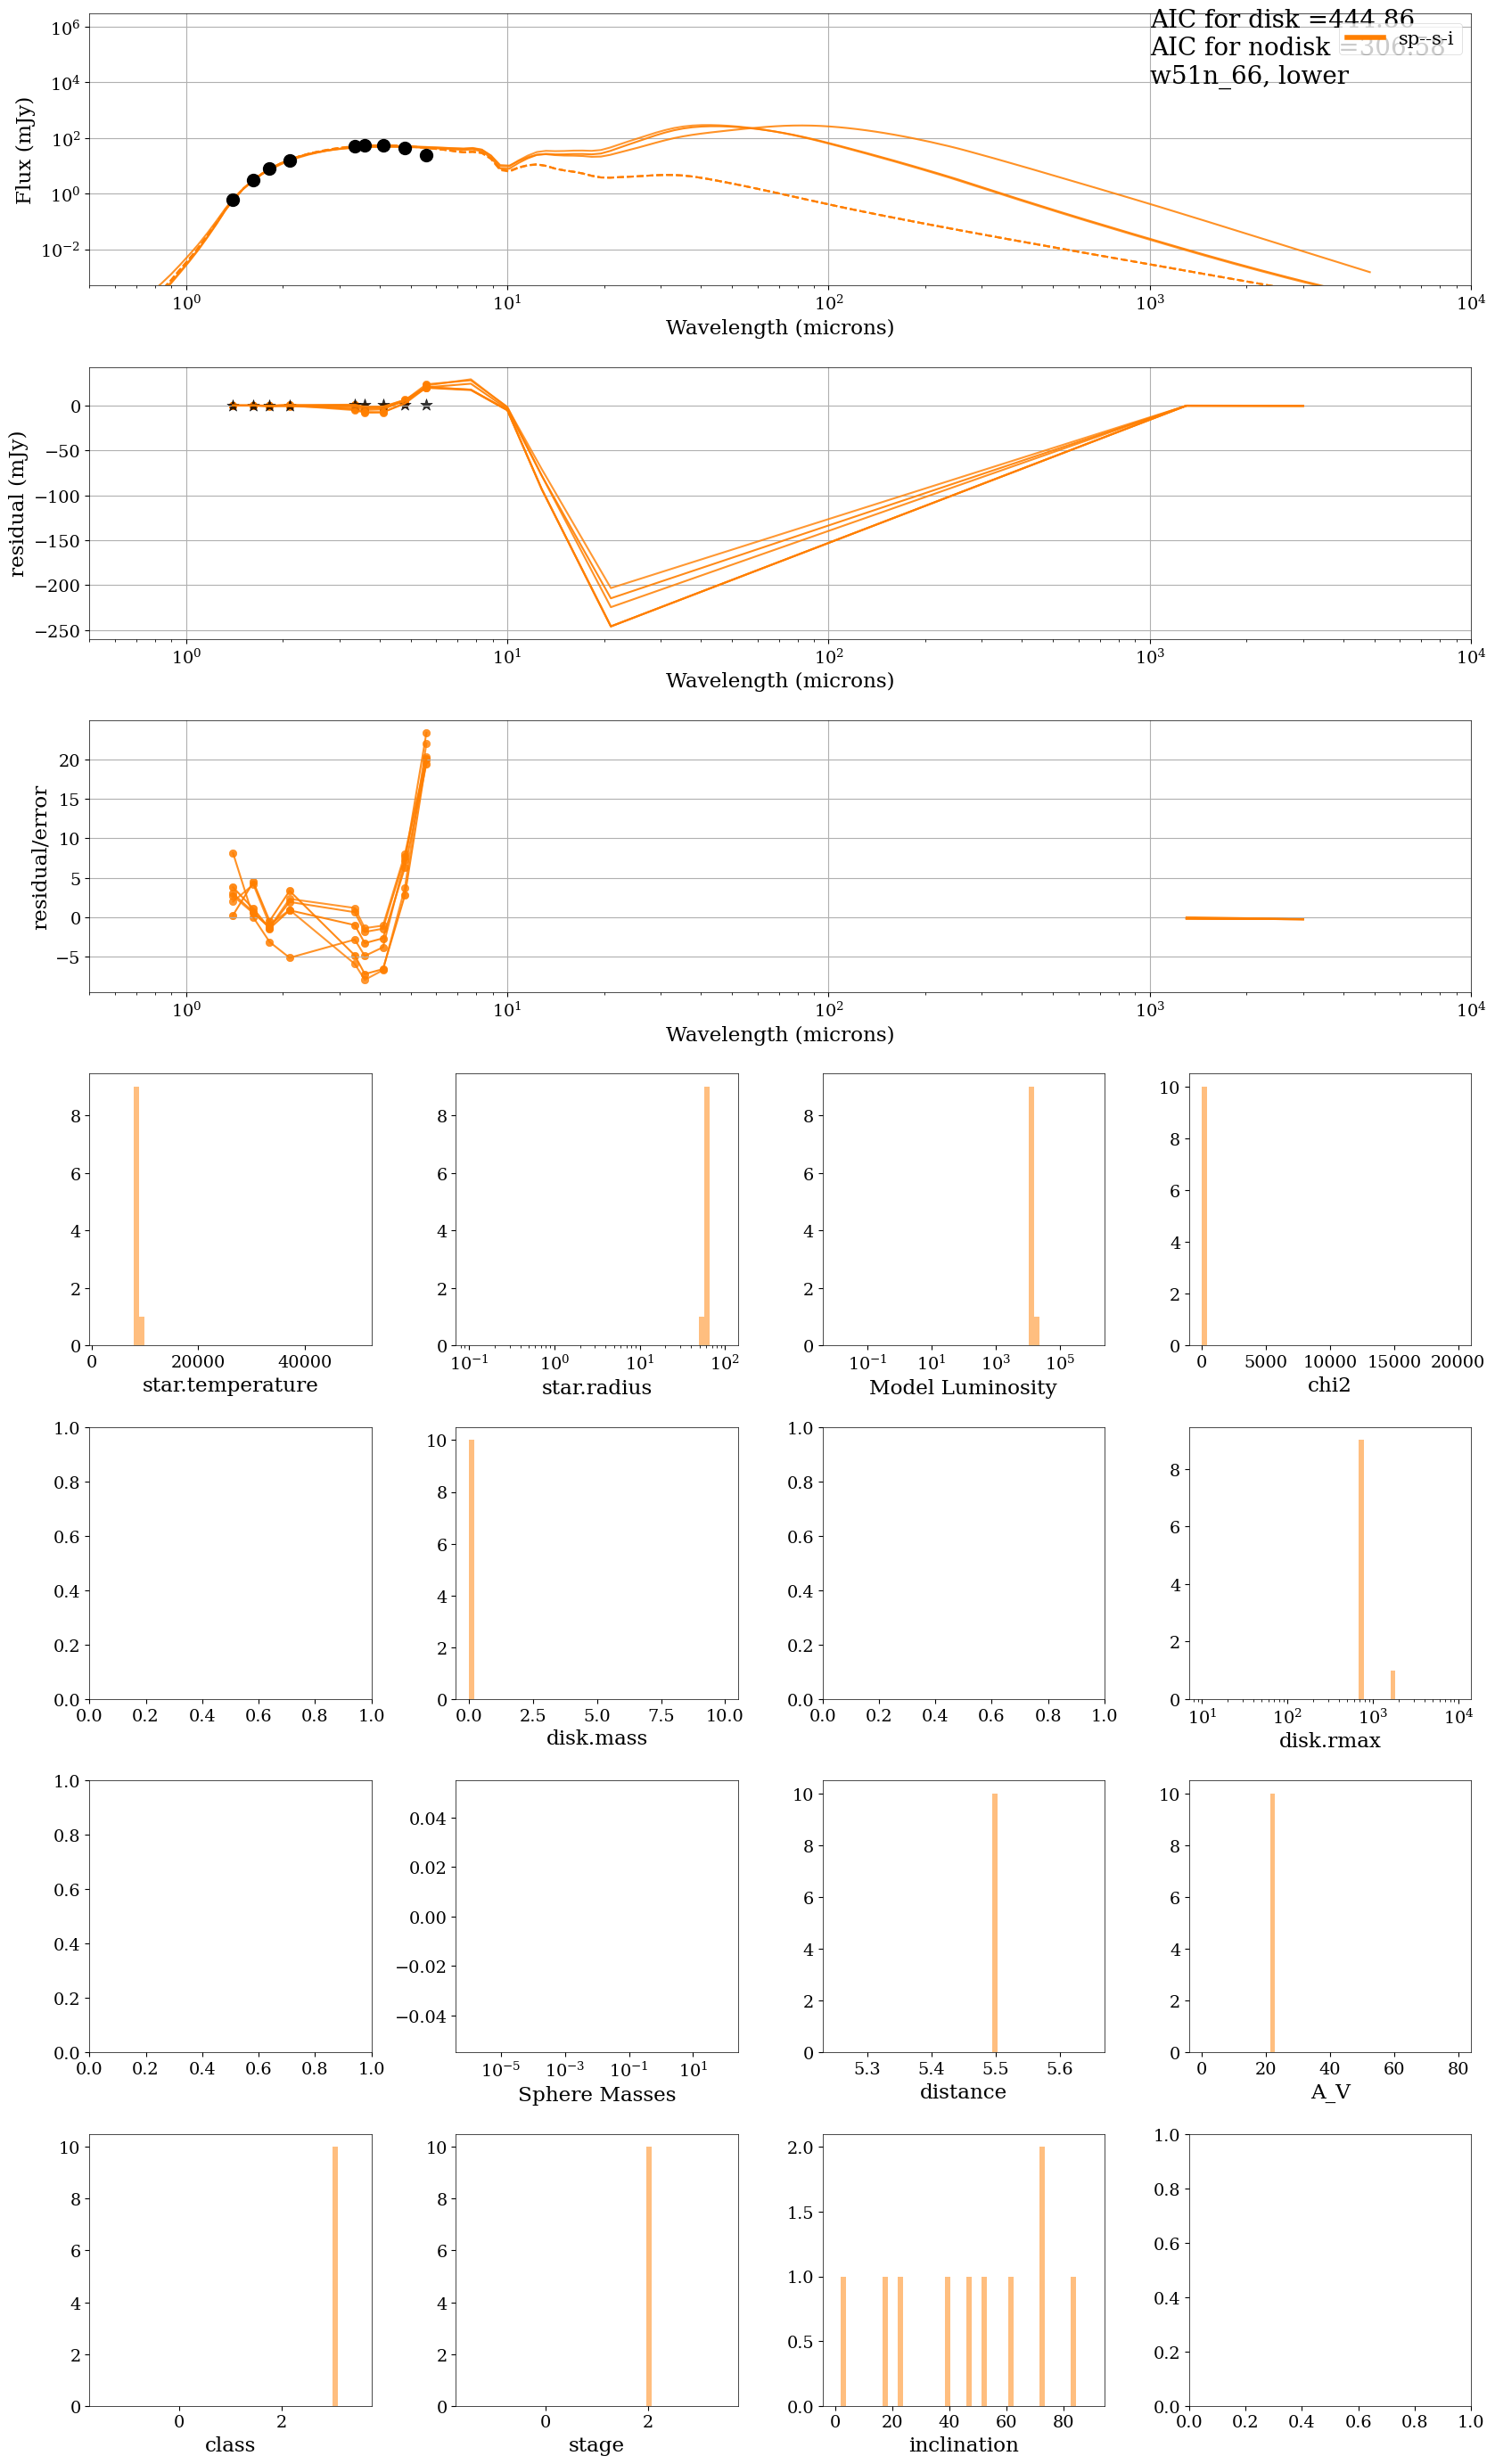

In [11]:
def plot_fit_models(fieldid, dict_to_write, fits_dict, apertures_arcsec, num_show=3, spicyid=0, label=None,
              distance_range=[5.25,5.65],
             extinction=None, 
             extinction_range=[0,80],
             robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/robitaille_models-1.2',
             loc_imagedir=None):

    """
    Parameters
    ----------
    fieldid : string
        'G328' (ex. - whatever your region is)
    dict_to_write : dict
        contains the data to be written to the plot
    fits : dict
        contains 18 sedfitter.fit_info.FitInfo objects, labeled per geometry
    okgeo : list
        contains strings (the labels of the best-fit geometries)
    wavelength_dict : dict
        entry ex. "'UKIRT/UKIDSS.J': <Quantity 12510.1752769 Angstrom>"
    min_chi2 : number
        chi2 value to serve as lower bound for limiting models shown. 
        if None, min_chi2 will be recalculated for each geometry
    modelcount : number
        3525 (ex. - the number of 'good fit' models being incorporated into the plot)
    show_all_models : bool
        whether or not to show every model on the SED plot,
        instead of only the best fit from each geom
    alpha_allmodels : number
        override the transparency of the SED models shown
    default_aperture : Quantity
        3000*u.au (ex. - default aperture size)
    show_per_aperture : bool
        whether or not to show per aperture
    extinction : sedfitter.extinction.extinction.Extinction
        created with make_extinction()
    extinction_range : array containing two numbers
        [0,40] (ex. - the presumed lower and upper bounds on extinction)
    robitaille_modeldir : string
        filepath to the Robitaille models 
    loc_imagedir : string
        filepath to the location images (This should be a single folder containing
        the location images for all sources to be fit, with the naming scheme of
        "[fieldid]_[spicyid].png". plot_fit won't break if the image is missing.
    """
    
    # --------------------------------
    # Set up plot surface
    # --------------------------------
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    from matplotlib.lines import Line2D

    params = ['star.temperature', 'star.radius', 'Model Luminosity', 'chi2', 'Line-of-Sight Masses', 'disk.mass', 'disk.rmin', 'disk.rmax', 'envelope.rmin', 'Sphere Masses', 'distance', 'A_V', 'class', 'stage', 'inclination', 'cavity.theta_0']
    log_scale_params = ['star.radius', 'Model Luminosity', 'Line-of-Sight Masses', 'disk.rmin', 'disk.rmax', 'envelope.rmin', 'Sphere Masses']
    binminmax = {'star.temperature':[2000,50000], 'star.radius':[0.1,100], 'Model Luminosity':[0.01,1e6], 'chi2':[0,20000], 'Line-of-Sight Masses':[0.01,100], 
    'disk.mass':[0,10], 'disk.rmin':[0.1,1000], 'disk.rmax':[10,10000], 'envelope.rmin':[0.1,10000], 'Sphere Masses':[1e-6,1e2], 'distance':[5.25,5.65], 'A_V':[0,80], 'class':[-1.5,3.5], 'stage':[-1.5,3.5], 'inclination':[0,90], 'cavity.theta_0':[5,90]}
    num_params = len(params)
    basefig = plt.figure(figsize=(20, 40))
    gs = GridSpec(nrows=num_params//4+4, ncols=4, hspace=0.3, wspace=0.3)
    plt.rcParams.update({'font.size': 20})

    # --------------------------------
    # Top-right: Best fits plot
    # --------------------------------
    
    ax0 = basefig.add_subplot(gs[0, :])
    ax1 = basefig.add_subplot(gs[1, :])
    #ax2 = basefig.add_subplot(gs[1, 3])
    ax3 = basefig.add_subplot(gs[2, :])
    
    colors = {}
    all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
    all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]

    for ii, geom in enumerate(all_gs):
        colors[geom] = plt.cm.Set1(ii / len(all_gs))
    # gather some information consistent across all geoms
    fitinfo = fits_dict[all_gs[0]]
    source = fitinfo.source
    valid = source.valid

    idx_valid1 = np.where(valid==1)[0]
    idx_valid2 = np.where(valid==2)[0]
    idx_valid3 = np.where(valid==3)[0]

    #found inconsistency between sed_filters and fitinfo.meta.filters
    
    if fieldid in ['G10','G12','W43MM1','W43MM2','W43MM3','W51-E','W51IRS2']:
        sed_filters, wavelength_dict, filternames, zpts = table_loading.get_filters("north")
    elif fieldid in ['G008','G327','G328','G333','G337','G338','G351','G353']:
        sed_filters, wavelength_dict, filternames, zpts = table_loading.get_filters("south")
    #for sed_filter in sed_filters:
    #    print(sed_filter.central_wavelength)
    #print(fitinfo.meta.filters)
    filters=filternames+["ALMA-IMF_1mm", "ALMA-IMF_3mm"]
    wavelengths = u.Quantity([wavelength_dict[fn] for fn in filters], u.um)
    wavelengths = [x['wav'] for x in fitinfo.meta.filters]
    wavelengths_value = [x['wav'].value for x in fitinfo.meta.filters]
    apertures = u.Quantity([x["aperture_arcsec"] for x in fitinfo.meta.filters], u.arcsec)

    #apertures_value = [x['aperture_arcsec'].value for x in fitinfo.meta.filters]
    #apertures = u.Quantity([apertures[i] for i in range(len((filters)))], u.arcsec)
    #source = [source[i] for i in range(len(filters))]
    #valid = [valid[i] for i in range(len(filters))]

    
    #distance = (10**fitinfo.sc * u.kpc).mean()

    # preserve this parameter before loop
    
    # store colors per geometry
  
    lss = ['solid', 'dashed']
    for jj, disklabel in enumerate(['disk', 'nodisk']):
        geos = dict_to_write[f'geom_{disklabel}'][:num_show]
        modelids = dict_to_write[f'model_id_{disklabel}'][:num_show]
        distances = dict_to_write[f'distance_{disklabel}'][:num_show]
        modelnames = dict_to_write[f'model_name_{disklabel}'][:num_show]
        aics = dict_to_write[f'aic_{disklabel}'][:num_show]
        for ii, (geom, modelid) in enumerate(zip(geos, modelids)):
            fitinfo = fits_dict[geom]
            model_dir = f'{robitaille_modeldir}/{geom}'
            sedcube = SEDCube.read(f"{model_dir}/flux.fits",)
            index = np.where(fitinfo.model_id == modelid)[0][0]
            distance = 10**fitinfo.sc[index] * u.kpc
            apertures_au = (apertures * distance).to(u.au, u.dimensionless_angles())
            chi2 = fitinfo.chi2[index]
           
            modelname = fitinfo.model_name[index]
            if modelname != modelnames[ii]: #sanity check
                raise ValueError(f"Model name mismatch: {modelname} != {modelnames[ii]}")
            modelnames.append(modelname)
            sed = sedcube.get_sed(modelname)
            sed_wav = sed.wav
            aperture_of_wav = interp1d(
                                wavelengths_value,
                                apertures_au.to_value(u.au),
                                kind="linear",
                                bounds_error=False,
                                fill_value=(apertures_au[0].to_value(u.au), apertures_au[-1].to_value(u.au)),
                                )

            target_apertures_au = aperture_of_wav(sed_wav)
            model_apertures_au = sedcube.apertures.to_value(u.au)


            sed_flux = np.asarray(sed.flux.value)
            if sed_flux.shape[0] == len(model_apertures_au):
                # shape is (n_aperture, n_wave)
                log_sed_flux = np.log10(sed_flux)
                interp_axis = 0
            elif sed_flux.shape[1] == len(model_apertures_au):
                # shape is (n_wave, n_aperture)
                log_sed_flux = np.log10(sed_flux).T
                interp_axis = 0
            else:
                raise ValueError(
                    f"Cannot identify aperture axis: sed.flux.shape={sed.flux.shape}, "
                    f"len(sedcube.apertures)={len(model_apertures_au)}"
                )

            log_sed_flux_interp = interp1d(
                model_apertures_au,
                log_sed_flux,
                axis=interp_axis,
                kind="linear",
            
            
            )

            log_flux_grid = log_sed_flux_interp(target_apertures_au)

            # Pick the wavelength-matched diagonal: flux at aperture(wavelength_i), wavelength_i
            sed_flux_interp = 10 ** np.diagonal(log_flux_grid)

            # https://github.com/astrofrog/sedfitter/blob/41dee15bdd069132b7c2fc0f71c4e2741194c83e/sedfitter/sed/sed.py#L64
            av_scale = fitinfo.av[index]
            distance_scale = (1 * u.kpc / distance)**2
            av_scale_conv = np.array([
                10**(av_scale * extinction.get_av(wavelength).item())
                for wavelength in sedcube.wav
            ])

        
            line, = ax0.plot(sedcube.wav,
                    sed_flux_interp * distance_scale * av_scale_conv, color=colors[geom],
                    alpha=0.9-ii*0.05, ls=lss[jj])


            interpolated_sed = interp1d(sedcube.wav, sed_flux_interp * distance_scale * av_scale_conv)
            resid =  interpolated_sed(wavelengths_value) - source.flux
            ax1.plot(np.array(wavelengths_value), np.array(resid), color=colors[geom], alpha=0.9-ii*0.05)
            ax1.scatter(np.array(wavelengths_value)[idx_valid1], np.array(resid)[idx_valid1], marker='o', color=colors[geom], alpha=0.9-ii*0.05)
            #ax1.scatter(np.array(wavelengths_value)[idx_valid2], np.array(resid)[idx_valid2], marker='^', color=colors[geom], alpha=0.9-ii*0.05)
            #ax1.scatter(np.array(wavelengths_value)[idx_valid3], np.array(resid)[idx_valid3], marker='v', color=colors[geom], alpha=0.9-ii*0.05)

            ax3.plot(np.array(wavelengths_value), np.array(resid)/np.array(source.error), color=colors[geom], alpha=0.9-ii*0.05)
            ax3.scatter(np.array(wavelengths_value)[idx_valid1], np.array(resid)[idx_valid1]/np.array(source.error)[idx_valid1], marker='o', color=colors[geom], alpha=0.9-ii*0.05)
            #ax3.scatter(np.array(wavelengths_value)[idx_valid2], np.array(resid)[idx_valid2]/np.array(source.error)[idx_valid2], marker='^', color=colors[geom], alpha=0.9-ii*0.05)
            #ax3.scatter(np.array(wavelengths_value)[idx_valid3], np.array(resid)[idx_valid3]/np.array(source.error)[idx_valid3], marker='v', color=colors[geom], alpha=0.9-ii*0.05)





      
        #colors[geom] = line.get_color()

        

        """
        apnums = np.array([
            np.argmin(np.abs((apsize * distance).to(u.au, u.dimensionless_angles()) - sedcube.apertures))
            for apsize in apertures])
        wlids = np.array([
            np.argmin(np.abs(ww - sedcube.wav)) for ww in wavelengths])
        
        """
        #flux = np.array([sed.flux[apn, wavid].value for apn, wavid in zip(apnums, wlids)])
        
        
       # av_scale_conv = np.array([10**(fitinfo.av[index] * extinction.get_av(wavelength).item()) for wavelength in wavelengths])
        
       # flux = flux * distance_scale.value * av_scale_conv
        #ax0.scatter(wavelengths_value, flux, marker='s', s=apertures, c=line.get_color())
    ax1.scatter(np.array(wavelengths_value)[idx_valid1], np.array(source.error)[idx_valid1], marker='*' ,color='k', alpha=0.9-ii*0.05, s=100)

    ax1.set_xscale('log')
   
    ax1.set_xlabel('Wavelength (microns)')
    ax1.set_ylabel('residual (mJy)')
    ax1.set_xlim(0.5,1e4)

    ax3.set_xscale('log')
   
    ax3.set_xlabel('Wavelength (microns)')
    ax3.set_ylabel('residual/error')
    ax3.set_xlim(0.5,1e4)
    ax3.grid()
    geos_unique = np.unique(geos)
    legend_elements = []

    for geom in geos_unique:   
        legend_elements.append(Line2D([0], [0], lw=4, label=geom, color=colors[geom]))
    ax0.legend(handles=legend_elements, loc='upper right', fontsize=15)
   
    ax0.errorbar(np.array(wavelengths_value)[idx_valid1], np.array(source.flux)[idx_valid1], yerr=source.error[idx_valid1], linestyle='none', color='black', marker='o', markersize=10)
    #ax0.plot(np.array(wavelengths_value)[idx_valid3], np.array(source.flux)[idx_valid3], linestyle='none', color='black', marker='v', markersize=10)
    #ax0.plot(np.array(wavelengths_value)[idx_valid2], np.array(source.flux)[idx_valid2], linestyle='none', color='black', marker='^', markersize=10)
  
            
    ax0.loglog()
    ax0.set_xlabel('Wavelength (microns)')
    ax0.set_ylabel("Flux (mJy)")
    ax0.set_xlim(0.5,1e4)
    ax0.set_ylim(5e-4,3e6)
    aic_for_disk = dict_to_write[f'aic_disk'][:num_show]
    aic_for_nodisk = dict_to_write[f'aic_nodisk'][:num_show]
    ax0.text(1e3, 1e6, 'AIC for disk ={:.2f}'.format(aic_for_disk[0]), transform=ax0.transData)
    ax0.text(1e3, 1e5, 'AIC for nodisk ={:.2f}'.format(aic_for_nodisk[0]), transform=ax0.transData)
    ax0.grid()
    ax1.grid()

    if aic_for_nodisk[0] - aic_for_disk[0] != dict_to_write[f'delta_aic']:
        raise ValueError(f"Delta AIC mismatch: {aic_for_disk[0]} - {aic_for_nodisk[0]} != {dict_to_write[f'delta_aic']}")
    

    if label is not None:
        ax0.text(1e3, 1e4, label, transform=ax0.transData)

    if aic_for_disk[0] - aic_for_nodisk[0] < 0:
        disklabel = 'disk'
    else:
        disklabel = 'nodisk'
    geos_best = dict_to_write[f'geom_{disklabel}']
    modelids_best = dict_to_write[f'model_id_{disklabel}']
    modelnames_best = dict_to_write[f'model_name_{disklabel}']
    

    for i,p in enumerate(params):
        row = i//4 + 3
        col = i % 4
        ax = basefig.add_subplot(gs[row, col])
        for geo in all_gs:
            geo_idx = np.where(np.array(geos_best) == geo)[0]
            if len(geo_idx) >0:
                pars = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geo}_augmented.fits') 
                print('geo_idx:', geo_idx)
                modelname_matched = np.array(modelnames_best)[geo_idx]
                modelid_matched = np.array(modelids_best)[geo_idx]
                print('modelname_matched:', modelname_matched)
                print('modelid_matched:', modelid_matched)
                data_list = []
                for modelid, modelname in zip(modelid_matched, modelname_matched):
                    selection_for_pars = np.where(pars['MODEL_NAME'] == modelname)[0]
                    print('selection_for_pars:', selection_for_pars)
                    print('p:', p)
                    if p=='chi2' or p=='distance' or p=='A_V' or p=='class' or p=='stage':
                        index_for_fits = np.where(fits_dict[geo].model_id == modelid)[0]
                        if p=='chi2':
                            chi2_vals = (fits_dict[geo].chi2[index_for_fits]).ravel()
                            print('chi2_vals:', chi2_vals)
                            data_list.extend(chi2_vals.value.tolist())
                          
                        if p=='distance':
                            distance = 10 ** fits_dict[geo].sc[index_for_fits]
                            data_list.extend(distance.tolist())
                           
                        if p=='A_V':
                            av = fits_dict[geo].av[index_for_fits]
                            data_list.extend(np.atleast_1d(av.value).tolist())
                        if p=='class':
                            data_list.extend(class_dict[geo][selection_for_pars].tolist())
                           
                        if p=='stage':
                            data_list.extend(stage_dict[geo][selection_for_pars].tolist())
                            

                    elif p == 'Line-of-Sight Masses' or p=='Sphere Masses':
                        data = pars[selection_for_pars] 
                        if p in data.columns:
                            data_for_p = np.asarray(data[p][:,3], dtype=float).ravel()

                       
                            data_list.append(data_for_p)
                      
                    else:
                        data = pars[selection_for_pars] 
                        if p in data.columns:
                            data_for_p = data[p]
                            data_list.append(data_for_p)
                   
                print('data_list:', data_list)
                if len(data_list) >0:    
                    
                    if p in {'chi2', 'distance', 'A_V', 'class', 'stage'}:
                        data_for_p = np.asarray(data_list)
                    else:
                        data_for_p = np.concatenate(data_list)
                    if p in log_scale_params:
                        bins = np.logspace(np.log10(binminmax[p][0]), np.log10(binminmax[p][1]), 50)
                        ax.set_xscale('log')
                    else:
                        bins = np.linspace(binminmax[p][0], binminmax[p][1], 50)
                    ax.hist(data_for_p, bins=bins, alpha=0.5, color=colors[geo], label=geo)
                    ax.set_xlabel(p)



    plt.show()
if idx in matching_idx_w51e_arr:
    idx_match = np.where(np.array(matching_idx_w51e_arr) == idx)[0][0]
    alma_idx_match = w51e_matched_idx[idx_match]

    plot_fit_models('W51-E', dict_to_write_temp, fits_dict, fwhms_use, spicyid=idx,
        extinction=extinction, label=f'w51e_{alma_idx_match}, {branchlabel}',
    loc_imagedir=f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/plots/{branchlabel}s/', robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',)
if idx in matching_idx_w51n_arr:
    idx_match = np.where(np.array(matching_idx_w51n_arr) == idx)[0][0]
    alma_idx_match = w51n_matched_idx[idx_match]
    plot_fit_models('W51-E',  dict_to_write_temp, fits_dict, fwhms_use, spicyid=idx,
        extinction=extinction, label=f'w51n_{alma_idx_match}, {branchlabel}',
    loc_imagedir=f'/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/plots/{branchlabel}s/', robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',)

    